In [30]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Explore Dataset
Visualize the dataset and highlight the ground-truth anomalies using the provided labels.

In [31]:
# Config
# find files that follow the pattern "001_*.csv" in the specified directory
DATASET_DIRECTORY = Path("../datasets/TSB-AD-U")
PATTERN = "001_*.csv"
# DATASET_PATH = Path("../datasets/TSB-AD-U/001_*.csv")
FILES = list(DATASET_DIRECTORY.glob(PATTERN))
print(f"Found {len(FILES)} files matching the pattern '{PATTERN}':")
for file in FILES:
    print(f" - {file.name}")
if len(FILES) > 1:
    print("Multiple files found. Please specify the exact file to use.")
elif len(FILES) == 0:   
    print("No files found. Please check the directory and pattern.")
else:
    DATASET_PATH = FILES[0]
START_INDEX = 1900  # Starting point for the window
WINDOW_SIZE = 300  # Number of samples to display

Found 1 files matching the pattern '001_*.csv':
 - 001_NAB_id_1_Facility_tr_1007_1st_2014.csv


## Plot Dataset Window

Dataset shape: (4031, 1)
Labels shape: (4031,)
Anomaly index ranges:
 - 2014 to 2147 (size: 134)
 - 3328 to 3461 (size: 134)
 - 3956 to 4030 (size: 75)


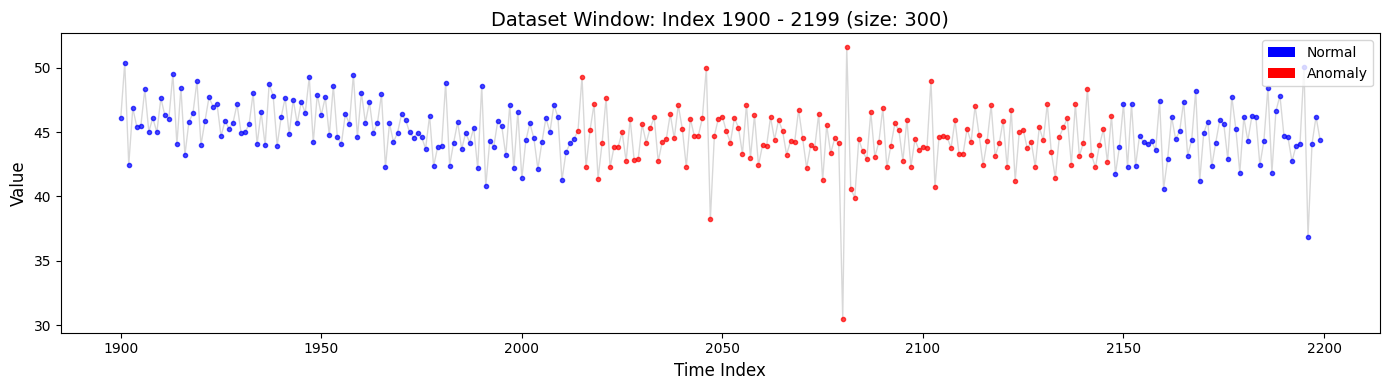

Anomalies in window: 134 / 300


In [32]:
from matplotlib.patches import Patch
# Load dataset
df = pd.read_csv(DATASET_PATH).dropna()
data = df.iloc[:, :-1].values.astype(float)
labels = df['Label'].astype(int).to_numpy()

print(f"Dataset shape: {data.shape}")
print(f"Labels shape: {labels.shape}")

# Print indices range of anomalies
anomaly_indices = np.where(labels == 1)[0]
# sort and combine consecutive indices into ranges
ranges = []
start = anomaly_indices[0]
for i in range(1, len(anomaly_indices)):
    if anomaly_indices[i] != anomaly_indices[i-1] + 1:
        ranges.append((start, anomaly_indices[i-1]))
        start = anomaly_indices[i]
ranges.append((start, anomaly_indices[-1]))  # add the last range
print("Anomaly index ranges:")
for start, end in ranges:
    print(f" - {start} to {end} (size: {end - start + 1})")

# Extract the window
end_index = min(START_INDEX + WINDOW_SIZE, len(data))
window_data = data[START_INDEX:end_index]
window_labels = labels[START_INDEX:end_index]
indices = np.arange(START_INDEX, end_index)

# Create the plot
fig, ax = plt.subplots(figsize=(14, 4))

# Plot data points colored by label
for i, (idx, point) in enumerate(zip(indices, window_data)):
    color = 'red' if window_labels[i] == 1 else 'blue'
    ax.plot(idx, point, 'o', color=color, markersize=3, alpha=0.7)

# Add line connecting points for better visibility
ax.plot(indices, window_data, color='gray', alpha=0.3, linewidth=1, zorder=0)

# Add labels and legend
ax.set_xlabel('Time Index', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title(f'Dataset Window: Index {START_INDEX} - {end_index-1} (size: {len(window_data)})', fontsize=14)

# Create custom legend
legend_elements = [
    Patch(facecolor='blue', label='Normal'),
    Patch(facecolor='red', label='Anomaly')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

print(f"Anomalies in window: {np.sum(window_labels)} / {len(window_labels)}")